In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from datetime import datetime
import warnings
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score


warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid")

# Teams

In [2]:
home= "Everton"
away= "Arsenal"

In [3]:
df_home= pd.read_csv(f"../Data/{home}.csv")
df_home["Date"] = pd.to_datetime(df_home["Date"]) 
df_home.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,G-PK,PK,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
25,Everton,Manchester Utd,2025-02-22,D,H,2,2,0,2,0,...,1.1,0.9,0.4,0.4,-0.1,0.21,0,0.3,0.09,-1.7
26,Everton,Brentford,2025-02-26,D,A,1,1,0,1,0,...,1.0,0.5,-0.5,-0.5,0.0,0.11,0,0.9,0.30,-0.1
27,Everton,Wolves,2025-03-08,D,A,1,1,0,1,0,...,1.2,0.7,-0.2,-0.2,-0.2,0.12,0,1.1,0.37,0.1
28,Everton,West Ham,2025-03-15,D,H,1,1,0,1,0,...,0.9,1.5,0.0,0.0,0.1,0.08,0,1.7,0.36,0.7
29,Everton,Liverpool,2025-04-02,L,A,0,1,-1,0,0,...,0.9,0.2,-0.9,-0.9,-0.9,0.18,0,0.3,0.09,-0.7


In [4]:
df_vs_home= pd.read_csv(f"../Data/vs {home}.csv")
df_vs_home["Date"] = pd.to_datetime(df_vs_home["Date"]) 
df_vs_home.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,G-PK,PK,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
25,Manchester Utd,Everton,2025-02-22,D,A,2,2,0,2,0,...,0.2,0.5,1.6,1.6,-0.2,0.05,2,1.5,0.20,-0.5
26,Brentford,Everton,2025-02-26,D,H,1,1,0,1,0,...,0.7,0.8,-0.4,-0.4,-0.7,0.14,0,2.4,0.60,1.4
27,Wolves,Everton,2025-03-08,D,H,1,1,0,1,0,...,0.7,0.6,0.2,0.2,0.3,0.07,1,1.5,0.37,0.5
28,West Ham,Everton,2025-03-15,D,A,1,1,0,1,0,...,0.6,0.7,0.2,0.2,0.4,0.08,0,1.4,0.29,0.4
29,Liverpool,Everton,2025-04-02,W,H,1,0,1,1,0,...,1.2,1.1,-0.5,-0.5,-0.2,0.09,1,0.0,NaN,0.0


In [5]:
df_away= pd.read_csv(f"../Data/{away}.csv")
df_away["Date"] = pd.to_datetime(df_away["Date"]) 
df_away.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,G-PK,PK,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
25,Arsenal,West Ham,2025-02-22,L,H,0,1,-1,0,0,...,1.0,1.6,-1.2,-1.2,-1.0,0.06,1,1.0,0.51,0.0
26,Arsenal,Nott'ham Forest,2025-02-26,D,A,0,0,0,0,0,...,1.0,0.9,-1.0,-1.0,-1.0,0.08,0,0.5,0.23,0.5
27,Arsenal,Manchester Utd,2025-03-09,D,A,1,1,0,1,0,...,1.1,1.3,-0.6,-0.6,-0.1,0.10,1,1.5,0.24,0.5
28,Arsenal,Chelsea,2025-03-16,W,H,1,0,1,1,0,...,0.4,0.7,0.3,0.3,0.6,0.06,1,0.2,0.10,0.2
29,Arsenal,Fulham,2025-04-01,W,H,2,1,1,2,0,...,2.0,1.3,-0.2,-0.2,0.0,0.14,0,1.0,0.34,0.0


In [6]:
df_vs_away= pd.read_csv(f"../Data/vs {away}.csv")
df_vs_away["Date"] = pd.to_datetime(df_away["Date"]) 
df_vs_away.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,G-PK,PK,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
25,West Ham,Arsenal,2025-02-22,W,A,1,0,1,1,0,...,1.1,0.6,-0.1,-0.1,-0.1,0.21,0,0.1,0.07,0.1
26,Nott'ham Forest,Arsenal,2025-02-26,D,H,0,0,0,0,0,...,0.3,0.3,-0.4,-0.4,-0.3,0.07,0,0.4,0.39,0.4
27,Manchester Utd,Arsenal,2025-03-09,D,H,1,1,0,1,0,...,0.8,0.8,-0.5,-0.5,-0.8,0.15,1,1.8,0.30,0.8
28,Chelsea,Arsenal,2025-03-16,L,A,0,1,-1,0,0,...,0.2,0.4,-0.4,-0.4,-0.2,0.04,0,0.7,0.17,-0.3
29,Fulham,Arsenal,2025-04-01,L,A,1,2,-1,1,0,...,0.8,1.0,0.0,0.0,0.2,0.11,0,1.8,0.46,-0.2


In [7]:
print(list(df_away.columns))

['Team', 'Opp', 'Date', 'Result', 'H/A', 'GF', 'GA', 'GD', 'G-PK', 'PK', 'PKatt', 'PKm', 'Poss', 'Att (GK)', 'Thr', 'Pa Launch%', 'Pa AvgLen', 'Won', 'Lost', 'Won%', 'Att To', 'Succ', 'Succ%', 'Tkld', 'Tkld%', 'Carries', 'TotDist', 'PrgDist', 'PrgC', 'Last3rd Car', 'OppCr', 'Stp', 'Stp%', 'CrdY', 'CrdR', '2CrdY', 'Fls', 'Fld', 'GCA', 'PassLive Gc', 'PassDead Gc', 'TO Gc', 'Sh-Gc', 'Fld Gc', 'Def-Gc', 'GK Att', 'Launch%', 'AvgLen', 'Sh', 'G/Sh', 'G/SoT', 'SoT', 'SoT%', 'Dist', 'FK', 'Off', 'PKwon', 'PKcon', 'OG', 'Recov', '#OPA', 'AvgDist', 'Cmp', 'Pas Att', 'Cmp%', 'KP', 'Last3rd PA', 'PPA', 'CrsPA', 'PrgP', 'TotDist Pas', 'PrgDist Pas', 'Cmp 5-15', 'Att 5-15', 'Cmp% 5-15', 'Cmp 15-30', 'Att 15-30', 'Cmp% 15-30', 'Cmp 30+', 'Att 30+', 'Cmp% 30+', 'PKdef', 'PKA', 'PKms', 'Missed PK%', 'PKAg', 'PKsv', 'PK Save%', 'FK Ag', 'CKG', 'OGK', 'Live Pas', 'Dead', 'Pas FK', 'TB', 'Sw', 'Crs', 'TI', 'CK', 'In', 'Out', 'Str', 'Ps Off', 'PTo', 'Rec', 'Last3rd Rec', 'CPA', 'Mis', 'Dis', 'SCA', 'PassL

# Desc

# Features

## Offense

In [8]:
offense= ['G-PK', 'PK', 'PKm', 'Poss', 'PKatt', 'Att To', 'Succ', 'Succ%', 'Tkld', 'Tkld%', 'Carries', 'TotDist', 'PrgDist', 
          'PrgC', 'Last3rd Car', 'GCA', 'PassLive Gc', 'PassDead Gc', 'TO Gc', 'Sh-Gc', 'Fld Gc', 'Def-Gc', 'Sh', 'G/Sh', 
          'G/SoT', 'SoT', 'SoT%', 'Dist', 'FK', 'Off', 'PKwon', 'Cmp', 'Pas Att', 'Cmp%', 'KP', 'Last3rd PA', 'PPA', 'CrsPA', 
          'PrgP', 'TotDist Pas', 'PrgDist Pas', 'Cmp 5-15', 'Att 5-15', 'Cmp% 5-15', 'Cmp 15-30', 'Att 15-30', 'Cmp% 15-30', 
          'Cmp 30+', 'Att 30+', 'Cmp% 30+', 'Live Pas', 'Dead', 'Pas FK', 'TB', 'Sw', 'Crs', 'TI', 'CK', 'In', 'Out', 'Str', 
          'Ps Off', 'PTo', 'Rec', 'Last3rd Rec', 'CPA', 'Mis', 'Dis', 'SCA', 'PassLive Sc', 'PassDead Sc', 'TO Sc', 'Sh-Sh', 
          'Fld Sc', 'Def-Sc', 'Touches', 'Def Pen', 'Tch Def 3rd', 'Tch Mid 3rd', 'Tch Att 3rd', 'Att Pen', 'Live Tch', 'xG', 
          'npxG', 'xGD', 'npxGD', 'xAG', 'xA', 'G-xG', 'np:G-xG', 'A-xAG', 'npxG/Sh', 'FKAtt', 'GF']

In [9]:
df_home_off= df_home[offense]
df_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
25,2,0,0,38,0,18,6,33.3,12,66.7,...,1.2,1.2,1.1,0.9,0.4,0.4,-0.1,0.21,0,2
26,1,0,0,48,0,10,4,40.0,6,60.0,...,0.1,0.1,1.0,0.5,-0.5,-0.5,0.0,0.11,0,1
27,1,0,0,34,0,9,5,55.6,4,44.4,...,0.5,0.5,1.2,0.7,-0.2,-0.2,-0.2,0.12,0,1
28,1,0,0,54,0,9,6,66.7,2,22.2,...,0.2,0.2,0.9,1.5,0.0,0.0,0.1,0.08,0,1
29,0,0,0,27,0,11,3,27.3,6,54.5,...,-0.6,-0.6,0.9,0.2,-0.9,-0.9,-0.9,0.18,0,0


In [10]:
df_vs_home_off= df_vs_home[offense]
df_vs_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
25,2,0,0,62,0,18,7,38.9,11,61.1,...,-1.2,-1.2,0.2,0.5,1.6,1.6,-0.2,0.05,2,2
26,1,0,0,52,0,21,9,42.9,11,52.4,...,-0.1,-0.1,0.7,0.8,-0.4,-0.4,-0.7,0.14,0,1
27,1,0,0,66,0,16,6,37.5,10,62.5,...,-0.5,-0.5,0.7,0.6,0.2,0.2,0.3,0.07,1,1
28,1,0,0,46,0,17,10,58.8,5,29.4,...,-0.2,-0.2,0.6,0.7,0.2,0.2,0.4,0.08,0,1
29,1,0,0,73,0,19,10,52.6,8,42.1,...,0.6,0.6,1.2,1.1,-0.5,-0.5,-0.2,0.09,1,1


In [11]:
df_away_off= df_away[offense]
df_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
25,0,0,0,68,0,13,7,53.8,4,30.8,...,0.1,0.1,1.0,1.6,-1.2,-1.2,-1.0,0.06,1,0
26,0,0,0,64,0,27,12,44.4,11,40.7,...,0.6,0.6,1.0,0.9,-1.0,-1.0,-1.0,0.08,0,0
27,1,0,0,68,0,24,9,37.5,14,58.3,...,0.1,0.1,1.1,1.3,-0.6,-0.6,-0.1,0.10,1,1
28,1,0,0,42,0,16,6,37.5,7,43.8,...,0.4,0.4,0.4,0.7,0.3,0.3,0.6,0.06,1,1
29,2,0,0,51,0,16,8,50.0,8,50.0,...,1.2,1.2,2.0,1.3,-0.2,-0.2,0.0,0.14,0,2


In [12]:
df_vs_away_off= df_vs_away[offense]
df_vs_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
25,1,0,0,32,0,15,6,40.0,5,33.3,...,-0.1,-0.1,1.1,0.6,-0.1,-0.1,-0.1,0.21,0,1
26,0,0,0,36,0,11,5,45.5,4,36.4,...,-0.6,-0.6,0.3,0.3,-0.4,-0.4,-0.3,0.07,0,0
27,1,0,0,32,0,6,2,33.3,4,66.7,...,-0.1,-0.1,0.8,0.8,-0.5,-0.5,-0.8,0.15,1,1
28,0,0,0,58,0,11,4,36.4,5,45.5,...,-0.4,-0.4,0.2,0.4,-0.4,-0.4,-0.2,0.04,0,0
29,1,0,0,49,0,17,7,41.2,10,58.8,...,-1.2,-1.2,0.8,1.0,0.0,0.0,0.2,0.11,0,1


## Defence

In [13]:
defence= ['OppCr', 'Stp', 'Stp%', 'PKcon', '#OPA', 'AvgDist', 'PKsv', 'PK Save%', 'FK Ag', 'CKG', 'OGK', 'SoTA', 'Saves', 
          'Save%', 'Tkl', 'TklW', 'Tkl Def 3rd', 'Tkl Mid 3rd', 'Tkl Att 3rd', 'Tkl.2', 'Tkl Att', 'Tkl%', 'Lost Tkl', 
          'Ints', 'BlcSh', 'Pass', 'Int', 'Tkl+Int', 'Clr', 'Err',  'PSxG', 'PSxG/SoT', 'PSxG+/-', 'GA']

In [14]:
df_home_def= df_home[defence]
df_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
25,19,1,5.3,0,0,3.0,0,NaN,1,0,...,3,5,9,33,35,0,0.3,0.09,-1.7,2
26,15,0,0.0,0,0,NaN,0,NaN,0,0,...,3,6,4,19,34,0,0.9,0.30,-0.1,1
27,15,1,6.7,0,1,13.0,0,NaN,0,0,...,3,9,8,40,36,1,1.1,0.37,0.1,1
28,11,0,0.0,0,2,16.8,0,NaN,0,0,...,1,11,9,24,28,0,1.7,0.36,0.7,1
29,23,2,8.7,0,1,10.5,0,NaN,0,0,...,9,13,12,29,47,0,0.3,0.09,-0.7,1


In [15]:
df_vs_home_def= df_vs_home[defence]
df_vs_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
25,19,1,5.3,0,1,23.5,0,NaN,0,1,...,1,6,13,37,36,0,1.5,0.20,-0.5,2
26,12,3,25.0,0,0,6.7,0,NaN,0,0,...,2,10,9,22,26,0,2.4,0.60,1.4,1
27,12,2,16.7,0,2,13.6,0,NaN,0,0,...,7,5,6,19,24,0,1.5,0.37,0.5,1
28,22,1,4.5,0,0,8.4,0,NaN,0,1,...,4,4,10,27,35,0,1.4,0.29,0.4,1
29,15,1,6.7,0,1,12.0,0,NaN,0,0,...,3,4,8,22,21,0,0.0,NaN,0.0,0


In [16]:
df_away_def= df_away[defence]
df_away_def.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
0,11,1,9.1,0,0,9.0,0,NaN,0,0,...,1,5,8,26,16,2,0.2,0.06,0.2,0
1,6,0,0.0,0,1,9.7,0,NaN,0,0,...,4,6,8,25,16,1,1.0,0.35,1.0,0
2,18,5,27.8,0,0,7.4,0,NaN,0,0,...,8,8,12,29,20,1,0.6,0.15,-0.4,1
3,25,2,8.0,0,2,12.4,0,NaN,0,0,...,5,11,9,30,32,1,0.3,0.06,0.3,0
4,18,3,16.7,0,0,6.0,0,NaN,0,1,...,13,8,4,20,41,1,2.2,0.20,0.2,2


In [17]:
df_vs_away_def= df_vs_away[defence]
df_vs_away_def.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
0,11,1,9.1,0,2,15.8,0,NaN,0,0,...,6,7,7,26,13,0,1.7,0.28,-0.3,2
1,8,1,12.5,0,0,10.3,0,NaN,0,0,...,1,3,4,26,17,1,0.9,0.22,-1.1,2
2,6,0,0.0,0,2,25.0,0,NaN,0,0,...,2,4,5,23,12,0,2.4,0.34,1.4,1
3,9,0,0.0,0,1,13.0,0,NaN,0,1,...,3,10,9,29,23,0,1.4,0.35,0.4,1
4,7,0,0.0,0,2,23.3,0,NaN,0,1,...,0,2,3,13,9,1,1.5,0.49,-0.5,2


## Combined

In [18]:
combined= ['Won', 'Lost', 'Won%', 'CrdY', 'CrdR', '2CrdY', 'Fls', 'Fld', 'Recov']

In [19]:
df_home_cmb= df_home[combined]
df_home_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
25,20,19,51.3,4,0,0,12,9,41
26,16,14,53.3,1,0,0,6,3,39
27,15,9,62.5,2,0,0,16,10,35
28,20,24,45.5,1,0,0,12,8,37
29,24,14,63.2,2,0,0,11,7,37


In [20]:
df_vs_home_cmb= df_vs_home[combined]
df_vs_home_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
25,19,20,48.7,1,0,0,9,11,46
26,14,16,46.7,2,0,0,3,5,37
27,9,15,37.5,2,0,0,11,16,43
28,24,20,54.5,2,0,0,8,12,39
29,14,24,36.8,2,0,0,7,11,36


In [21]:
df_away_cmb= df_away[combined]
df_away_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
25,17,19,47.2,1,1,0,16,14,33
26,16,14,53.3,1,0,0,17,9,35
27,10,13,43.5,1,0,0,11,6,37
28,13,8,61.9,3,0,0,10,13,35
29,9,18,33.3,1,0,0,2,10,34


In [22]:
df_vs_away_cmb= df_vs_away[combined]
df_vs_away_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
25,19,17,52.8,3,0,0,15,16,34
26,14,16,46.7,1,0,0,10,15,34
27,13,10,56.5,0,0,0,8,9,34
28,8,13,38.1,3,0,0,13,9,28
29,18,9,66.7,2,0,0,10,2,28


## By Team

In [23]:
def create_lagged_features(df, target_cols, window= 4):
    """
    Creates lagged and rolling window features for a given dataset.
    
    Parameters:
    df (pd.DataFrame): The input dataframe containing game-by-game data.
    team_col (str): The column name representing the team.
    date_col (str): The column name representing the game date.
    target_cols (list): List of columns to create lagged and rolling features for.
    opponent_col (str, optional): Column representing the opponent team (if applicable).
    lags (list): List of lag periods to include.
    rolling_windows (list): List of rolling window sizes for moving averages and std dev.
    
    Returns:
    pd.DataFrame: Dataframe with additional lagged and rolling features.
    """
    df = df.copy()
    
    
    # Create lagged features for the given columns
    #for col in target_cols:
     #   for lag in range(1, window+1):
      #      df[f'{col}_lag_{lag}'] = df[col].shift(lag)
    
    # Create rolling window features (mean & std)
    for col in target_cols:
        df[f'{col}_rolling_avg_{window}'] = df[col].shift(1).rolling(window, min_periods= 1).mean()
        df[f'{col}_rolling_std_{window}'] = df[col].shift(1).rolling(window, min_periods= 1).std()
    
    # Fill NA values (after shifting to avoid data leakage)
    df = df.fillna(0)
    
    return df


In [24]:
df_home_off= create_lagged_features(df_home_off, offense)
df_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
25,2,0,0,38,0,18,6,33.3,12,66.7,...,0.875,0.684957,0.575,0.556028,0.1025,0.066018,0.0,0.0,2.25,1.258306
26,1,0,0,48,0,10,4,40.0,6,60.0,...,1.000,0.454606,0.550,0.591608,0.1475,0.061305,0.0,0.0,2.50,1.000000
27,1,0,0,34,0,9,5,55.6,4,44.4,...,0.500,0.734847,0.300,0.547723,0.1275,0.055603,0.0,0.0,1.75,0.500000
28,1,0,0,54,0,9,6,66.7,2,22.2,...,0.200,0.707107,-0.025,0.170783,0.1325,0.053151,0.0,0.0,1.50,0.577350
29,0,0,0,27,0,11,3,27.3,6,54.5,...,-0.075,0.377492,-0.050,0.129099,0.1300,0.055976,0.0,0.0,1.25,0.500000


In [25]:
df_vs_home_off= create_lagged_features(df_vs_home_off, offense)
df_vs_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
25,2,0,0,62,0,18,7,38.9,11,61.1,...,-0.050,0.981495,-0.100,0.469042,0.0725,0.032016,0.25,0.500000,0.75,0.957427
26,1,0,0,52,0,21,9,42.9,11,52.4,...,0.525,1.135415,-0.075,0.457347,0.0725,0.032016,0.75,0.957427,1.25,0.957427
27,1,0,0,66,0,16,6,37.5,10,62.5,...,0.500,1.160460,-0.175,0.556028,0.0975,0.036856,0.50,1.000000,1.50,0.577350
28,1,0,0,46,0,17,10,58.8,5,29.4,...,0.200,0.993311,-0.250,0.420317,0.0900,0.039158,0.75,0.957427,1.25,0.500000
29,1,0,0,73,0,19,10,52.6,8,42.1,...,0.400,0.848528,-0.050,0.506623,0.0850,0.038730,0.75,0.957427,1.25,0.500000


In [26]:
df_away_def= create_lagged_features(df_away_def, defence)
df_away_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
25,5,2,40.0,0,4,22.6,0,0.0,0,0,...,0.25,0.50000,0.825,0.585235,0.2225,0.130735,0.075,0.492443,0.75,0.957427
26,14,0,0.0,0,0,10.0,0,0.0,0,0,...,0.00,0.00000,0.700,0.424264,0.2550,0.186994,0.200,0.336650,0.50,0.577350
27,10,1,10.0,0,1,15.0,0,0.0,1,0,...,0.25,0.50000,0.650,0.435890,0.2675,0.181911,0.150,0.238048,0.50,0.577350
28,7,2,28.6,0,6,20.6,0,0.0,0,0,...,0.25,0.50000,0.775,0.607591,0.2625,0.182460,0.275,0.262996,0.50,0.577350
29,12,0,0.0,0,2,22.8,0,0.0,0,0,...,0.50,0.57735,0.800,0.571548,0.2700,0.172240,0.300,0.244949,0.50,0.577350


In [27]:
df_vs_away_def= create_lagged_features(df_vs_away_def, defence)
df_vs_away_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
25,23,0,0.0,0,0,5.0,0,0.0,0,0,...,1.75,1.707825,1.875,0.942956,0.3425,0.084607,-0.625,0.925113,2.50,1.732051
26,25,0,0.0,0,0,13.5,0,0.0,0,0,...,2.00,1.632993,1.450,1.302562,0.2825,0.163580,-0.550,0.981495,2.00,2.160247
27,23,1,4.3,0,0,6.8,0,0.0,0,0,...,2.25,1.258306,1.375,1.367175,0.3200,0.167730,-0.375,1.096586,1.75,2.362908
28,11,0,0.0,0,1,10.8,0,0.0,0,1,...,1.50,0.577350,1.075,0.963933,0.2875,0.151079,0.325,0.359398,0.75,0.957427
29,19,1,5.3,0,0,10.0,0,0.0,0,0,...,1.50,0.577350,0.750,0.741620,0.2325,0.141038,0.250,0.465475,0.50,0.577350


In [28]:
df_away_off= create_lagged_features(df_away_off, offense)
df_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
25,0,0,0,68,0,13,7,53.8,4,30.8,...,1.325,1.809926,1.050,1.569501,0.0975,0.027538,0.25,0.50000,2.50,1.732051
26,0,0,0,64,0,27,12,44.4,11,40.7,...,0.850,2.229350,0.525,1.869715,0.0950,0.031091,0.50,0.57735,2.00,2.160247
27,1,0,0,68,0,24,9,37.5,14,58.3,...,0.600,2.405549,0.450,1.939931,0.0875,0.029861,0.25,0.50000,1.75,2.362908
28,1,0,0,42,0,16,6,37.5,7,43.8,...,-0.550,0.806226,-0.350,0.818535,0.0925,0.029861,0.50,0.57735,0.75,0.957427
29,2,0,0,51,0,16,8,50.0,8,50.0,...,-0.625,0.665207,-0.375,0.776209,0.0750,0.019149,0.75,0.50000,0.50,0.577350


In [29]:
df_vs_away_off= create_lagged_features(df_vs_away_off, offense)
df_vs_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
25,1,0,0,32,0,15,6,40.0,5,33.3,...,0.075,0.718215,0.125,0.750000,0.0925,0.041130,0.00,0.0,0.75,0.957427
26,0,0,0,36,0,11,5,45.5,4,36.4,...,-0.200,0.374166,-0.175,0.377492,0.1125,0.072744,0.00,0.0,0.50,0.577350
27,1,0,0,32,0,6,2,33.3,4,66.7,...,-0.125,0.250000,-0.075,0.206155,0.1100,0.074386,0.00,0.0,0.50,0.577350
28,0,0,0,58,0,11,4,36.4,5,45.5,...,-0.300,0.182574,-0.325,0.330404,0.1175,0.077190,0.25,0.5,0.50,0.577350
29,1,0,0,49,0,17,7,41.2,10,58.8,...,-0.350,0.173205,-0.350,0.310913,0.1175,0.077190,0.25,0.5,0.50,0.577350


In [30]:
df_home_def= create_lagged_features(df_home_def, defence)
df_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
25,19,1,5.3,0,0,3.0,0,0.0,1,0,...,0.50,0.57735,1.025,0.809835,0.340,0.227596,0.275,0.537742,0.75,0.957427
26,15,0,0.0,0,0,0.0,0,0.0,0,0,...,0.50,0.57735,0.950,0.873689,0.210,0.160624,-0.300,1.055146,1.25,0.957427
27,15,1,6.7,0,1,13.0,0,0.0,0,0,...,0.25,0.50000,1.150,0.685565,0.270,0.127279,-0.350,1.034408,1.50,0.577350
28,11,0,0.0,0,2,16.8,0,0.0,0,0,...,0.50,0.57735,1.025,0.618466,0.265,0.121244,-0.225,1.056330,1.25,0.500000
29,23,2,8.7,0,1,10.5,0,0.0,0,0,...,0.25,0.50000,1.000,0.577350,0.280,0.130384,-0.250,1.024695,1.25,0.500000


In [31]:
df_vs_home_def= create_lagged_features(df_vs_home_def, defence)
df_vs_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
25,19,1,5.3,0,1,23.5,0,0.0,0,1,...,1.00,1.414214,1.475,0.704154,0.2450,0.180647,-0.775,0.573730,2.25,1.258306
26,12,3,25.0,0,0,6.7,0,0.0,0,0,...,1.00,1.414214,1.625,0.596518,0.2950,0.099833,-0.875,0.434933,2.50,1.000000
27,12,2,16.7,0,2,13.6,0,0.0,0,0,...,0.75,1.500000,1.600,0.547723,0.3550,0.186458,-0.150,1.040833,1.75,0.500000
28,22,1,4.5,0,0,8.4,0,0.0,0,1,...,0.75,1.500000,1.675,0.492443,0.3475,0.184639,0.175,0.970824,1.50,0.577350
29,15,1,6.7,0,1,12.0,0,0.0,0,0,...,0.00,0.000000,1.700,0.469042,0.3650,0.171367,0.450,0.776745,1.25,0.500000


In [32]:
df_home_cmb.rename(columns= {col: f"h_{col}" for col in df_home_cmb.columns}, inplace= True)
df_home_cmb= create_lagged_features(df_home_cmb, df_home_cmb.columns)
df_home_cmb.tail()

,h_Won,h_Lost,h_Won%,h_CrdY,h_CrdR,h_2CrdY,h_Fls,h_Fld,h_Recov,h_Won_rolling_avg_4,...,h_CrdR_rolling_avg_4,h_CrdR_rolling_std_4,h_2CrdY_rolling_avg_4,h_2CrdY_rolling_std_4,h_Fls_rolling_avg_4,h_Fls_rolling_std_4,h_Fld_rolling_avg_4,h_Fld_rolling_std_4,h_Recov_rolling_avg_4,h_Recov_rolling_std_4
25,20,19,51.3,4,0,0,12,9,41,22.75,...,0.25,0.5,0.25,0.5,9.75,2.217356,12.00,5.291503,41.25,3.500000
26,16,14,53.3,1,0,0,6,3,39,22.00,...,0.25,0.5,0.25,0.5,10.00,2.449490,12.50,4.725816,42.25,2.217356
27,15,9,62.5,2,0,0,16,10,35,22.00,...,0.25,0.5,0.25,0.5,9.75,2.872281,10.00,6.633250,40.75,1.707825
28,20,24,45.5,1,0,0,12,8,37,20.75,...,0.00,0.0,0.00,0.0,11.50,4.123106,7.75,3.201562,38.75,2.629956
29,24,14,63.2,2,0,0,11,7,37,17.75,...,0.00,0.0,0.00,0.0,11.50,4.123106,7.50,3.109126,38.00,2.581989


In [33]:
df_vs_home_cmb.rename(columns= {col: f"vh_{col}" for col in df_vs_home_cmb.columns}, inplace= True)
df_vs_home_cmb= create_lagged_features(df_vs_home_cmb, df_vs_home_cmb.columns)
df_vs_home_cmb.tail()

,vh_Won,vh_Lost,vh_Won%,vh_CrdY,vh_CrdR,vh_2CrdY,vh_Fls,vh_Fld,vh_Recov,vh_Won_rolling_avg_4,...,vh_CrdR_rolling_avg_4,vh_CrdR_rolling_std_4,vh_2CrdY_rolling_avg_4,vh_2CrdY_rolling_std_4,vh_Fls_rolling_avg_4,vh_Fls_rolling_std_4,vh_Fld_rolling_avg_4,vh_Fld_rolling_std_4,vh_Recov_rolling_avg_4,vh_Recov_rolling_std_4
25,19,20,48.7,1,0,0,9,11,46,19.25,...,0.25,0.5,0.25,0.5,12.50,5.446712,9.50,2.645751,41.25,4.856267
26,14,16,46.7,2,0,0,3,5,37,19.00,...,0.25,0.5,0.25,0.5,12.75,5.188127,9.50,2.645751,41.25,4.856267
27,9,15,37.5,2,0,0,11,16,43,19.25,...,0.25,0.5,0.25,0.5,10.25,7.088723,9.25,3.095696,40.50,5.322906
28,24,20,54.5,2,0,0,8,12,39,16.00,...,0.00,0.0,0.00,0.0,8.00,3.464102,11.00,4.546061,42.50,3.872983
29,14,24,36.8,2,0,0,7,11,36,16.50,...,0.00,0.0,0.00,0.0,7.75,3.403430,11.00,4.546061,41.25,4.031129


In [34]:
df_away_cmb.rename(columns= {col: f"va_{col}" for col in df_away_cmb.columns}, inplace= True)
df_away_cmb= create_lagged_features(df_away_cmb, df_away_cmb.columns)
df_away_cmb.tail()

,va_Won,va_Lost,va_Won%,va_CrdY,va_CrdR,va_2CrdY,va_Fls,va_Fld,va_Recov,va_Won_rolling_avg_4,...,va_CrdR_rolling_avg_4,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4
25,17,19,47.2,1,1,0,16,14,33,10.75,...,0.25,0.50000,0.0,0.0,9.00,2.000000,13.25,6.238322,40.25,2.061553
26,16,14,53.3,1,0,0,17,9,35,11.25,...,0.50,0.57735,0.0,0.0,10.50,4.123106,12.50,5.802298,39.00,4.242641
27,10,13,43.5,1,0,0,11,6,37,13.50,...,0.25,0.50000,0.0,0.0,12.25,5.188127,9.75,2.986079,37.25,4.031129
28,13,8,61.9,3,0,0,10,13,35,14.50,...,0.25,0.50000,0.0,0.0,13.50,3.511885,9.50,3.316625,36.75,3.862210
29,9,18,33.3,1,0,0,2,10,34,14.00,...,0.25,0.50000,0.0,0.0,13.50,3.511885,10.50,3.696846,35.00,1.632993


In [35]:
df_vs_away_cmb.rename(columns= {col: f"a_{col}" for col in df_vs_away_cmb.columns}, inplace= True)
df_vs_away_cmb= create_lagged_features(df_vs_away_cmb, df_vs_away_cmb.columns)
df_vs_away_cmb.tail()

,a_Won,a_Lost,a_Won%,a_CrdY,a_CrdR,a_2CrdY,a_Fls,a_Fld,a_Recov,a_Won_rolling_avg_4,...,a_CrdR_rolling_avg_4,a_CrdR_rolling_std_4,a_2CrdY_rolling_avg_4,a_2CrdY_rolling_std_4,a_Fls_rolling_avg_4,a_Fls_rolling_std_4,a_Fld_rolling_avg_4,a_Fld_rolling_std_4,a_Recov_rolling_avg_4,a_Recov_rolling_std_4
25,19,17,52.8,3,0,0,15,16,34,11.00,...,0.25,0.5,0.25,0.5,13.50,6.454972,8.50,1.732051,38.50,7.505553
26,14,16,46.7,1,0,0,10,15,34,12.50,...,0.25,0.5,0.25,0.5,12.75,5.909033,10.25,4.193249,39.50,6.137318
27,13,10,56.5,0,0,0,8,9,34,12.75,...,0.00,0.0,0.00,0.0,10.25,3.403430,11.75,4.645787,36.25,3.862210
28,8,13,38.1,3,0,0,13,9,28,14.25,...,0.00,0.0,0.00,0.0,10.50,3.109126,12.50,3.511885,36.00,4.000000
29,18,9,66.7,2,0,0,10,2,28,13.50,...,0.00,0.0,0.00,0.0,11.50,3.109126,12.25,3.774917,32.50,3.000000


In [36]:
df_home_off.drop(columns=['GF'], inplace= True)
df_away_off.drop(columns=['GF'], inplace= True)
df_vs_home_off.drop(columns=['GF'], inplace= True)
df_vs_away_off.drop(columns=['GF'], inplace= True)

df_home_def.drop(columns=['GA'], inplace= True)
df_away_def.drop(columns=['GA'], inplace= True)
df_vs_home_def.drop(columns=['GA'], inplace= True)
df_vs_away_def.drop(columns=['GA'], inplace= True)

## Final DFs

In [37]:
df_home_frw= pd.concat([df_home_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True), 
                        df_away_def[-1:].reset_index(drop=True),
                        ], 
                        axis= 1
                        )
#df_home_frw["Tm_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
#df_home_frw["Opp_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
df_home_frw["H/A"]= "H"
df_home_frw

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4,H/A
0,0,0,0,27,0,11,3,27.3,6,54.5,...,0.57735,0.8,0.571548,0.27,0.17224,0.3,0.244949,0.5,0.57735,H


In [38]:
df_home_gf= pd.concat([df_home_off[:-1], 
                       df_vs_home_def[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True), 
                       df_home[['H/A', 'GF']][1:].reset_index(drop=True)
                       ], 
                       axis= 1
                       )
df_home_gf.head()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GF
0,0,0,0,40,0,16,5,31.3,11,68.8,...,0.000000,0.00000,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,A,0
1,0,0,0,30,0,22,5,22.7,16,72.7,...,0.000000,0.00000,17.00,0.000000,14.000000,0.000000,30.000000,0.000000,H,2
2,2,0,0,47,0,21,10,47.6,9,42.9,...,0.000000,0.00000,16.50,0.707107,11.000000,4.242641,31.500000,2.121320,A,2
3,2,0,0,28,0,22,7,31.8,12,54.5,...,0.333333,0.57735,15.00,2.645751,9.666667,3.785939,33.333333,3.511885,A,1
4,1,0,0,42,0,22,7,31.8,13,59.1,...,0.250000,0.50000,13.75,3.304038,10.250000,3.304038,33.000000,2.943920,H,2


In [39]:
df_home_bcw= pd.concat([df_home_def[-1:].reset_index(drop=True), 
                        df_away_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_home_bcw["Tm_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
#df_home_bcw["Opp_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
df_home_bcw["H/A"]= "H"
df_home_bcw

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,23,2,8.7,0,1,10.5,0,0.0,0,0,...,0.5,0.0,0.0,13.5,3.511885,10.5,3.696846,35.0,1.632993,H


In [40]:
df_home_ga= pd.concat([df_home_def[:-1], 
                       df_vs_home_off[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True),
                       df_home[['H/A', 'GA']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_home_ga.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GA
0,8,1,12.5,0,5,25.4,0,0.0,0,0,...,0.000000,0.00000,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,A,4
1,14,0,0.0,0,2,14.8,0,0.0,0,1,...,0.000000,0.00000,17.00,0.000000,14.000000,0.000000,30.000000,0.000000,H,3
2,20,0,0.0,0,4,22.3,0,0.0,0,0,...,0.000000,0.00000,16.50,0.707107,11.000000,4.242641,31.500000,2.121320,A,3
3,15,0,0.0,0,2,19.8,0,0.0,0,0,...,0.333333,0.57735,15.00,2.645751,9.666667,3.785939,33.333333,3.511885,A,1
4,24,2,8.3,0,1,13.2,0,0.0,0,1,...,0.250000,0.50000,13.75,3.304038,10.250000,3.304038,33.000000,2.943920,H,1


In [41]:
df_away_frw= pd.concat([df_away_off[-1:].reset_index(drop=True), 
                        df_home_def[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_away_frw["Tm_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
#df_away_frw["Opp_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
df_away_frw["H/A"]= "A"
df_away_frw

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,2,0,0,51,0,16,8,50.0,8,50.0,...,0.5,0.0,0.0,13.5,3.511885,10.5,3.696846,35.0,1.632993,A


In [42]:
df_away_gf= pd.concat([df_away_off[:-1], 
                       df_vs_away_def[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True),
                       df_away[['H/A', 'GF']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_away_gf.head()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GF
0,2,0,0,53,0,22,9,40.9,10,45.5,...,0.000000,0.00000,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,A,2
1,2,0,0,60,0,17,6,35.3,9,52.9,...,0.000000,0.00000,17.00,0.000000,14.000000,0.000000,30.000000,0.000000,H,1
2,1,0,0,36,0,16,8,50.0,7,43.8,...,0.000000,0.00000,16.50,0.707107,11.000000,4.242641,31.500000,2.121320,A,1
3,1,0,0,37,0,22,12,54.5,8,36.4,...,0.333333,0.57735,15.00,2.645751,9.666667,3.785939,33.333333,3.511885,A,2
4,2,0,0,23,0,11,4,36.4,4,36.4,...,0.250000,0.50000,13.75,3.304038,10.250000,3.304038,33.000000,2.943920,H,4


In [43]:
df_away_bcw= pd.concat([df_away_def[-1:].reset_index(drop=True), 
                        df_home_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_away_bcw["Tm_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
#df_away_bcw["Opp_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
df_away_bcw["H/A"]= "H"
df_away_bcw

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,12,0,0.0,0,2,22.8,0,0.0,0,0,...,0.5,0.0,0.0,13.5,3.511885,10.5,3.696846,35.0,1.632993,H


In [44]:
df_away_ga= pd.concat([df_away_def[:-1], 
                       df_vs_away_off[:-1],
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True), 
                       df_away[['H/A', 'GA']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_away_ga.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GA
0,11,1,9.1,0,0,9.0,0,0.0,0,0,...,0.000000,0.00000,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,A,0
1,6,0,0.0,0,1,9.7,0,0.0,0,0,...,0.000000,0.00000,17.00,0.000000,14.000000,0.000000,30.000000,0.000000,H,1
2,18,5,27.8,0,0,7.4,0,0.0,0,0,...,0.000000,0.00000,16.50,0.707107,11.000000,4.242641,31.500000,2.121320,A,0
3,25,2,8.0,0,2,12.4,0,0.0,0,0,...,0.333333,0.57735,15.00,2.645751,9.666667,3.785939,33.333333,3.511885,A,2
4,18,3,16.7,0,0,6.0,0,0.0,0,1,...,0.250000,0.50000,13.75,3.304038,10.250000,3.304038,33.000000,2.943920,H,2


In [45]:
df_home_gf = df_home_gf.fillna(0)

In [46]:
df_home_ga = df_home_ga.fillna(0)

In [47]:
df_away_ga = df_away_ga.fillna(0)

In [48]:
df_away_gf = df_away_gf.fillna(0)

# Categories

In [49]:
# Define bins for football goals classification
bins = [-1, 0, 1, 2, 3, float('inf')]  # -1 to include 0 as a bin
labels = [0, 1, 2, 3, 4]  # Assigning numeric class labels

# Apply binning
df_home_gf['GFC'] = pd.cut(df_home_gf['GF'], bins=bins, labels=labels)
df_away_gf['GFC'] = pd.cut(df_away_gf['GF'], bins=bins, labels=labels)
df_home_ga['GAC'] = pd.cut(df_home_ga['GA'], bins=bins, labels=labels)
df_away_ga['GAC'] = pd.cut(df_away_ga['GA'], bins=bins, labels=labels)

In [50]:
df_home_gf.drop(columns=['GF'], inplace= True)
df_away_gf.drop(columns=['GF'], inplace= True)

df_home_ga.drop(columns=['GA'], inplace= True)
df_away_ga.drop(columns=['GA'], inplace= True)


# Models

## Classification

### Model Home

In [51]:
target = "GFC"  # Goals For

# Separate features and target
X = df_home_gf.drop(columns=[target])
y = df_home_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [52]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [53]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

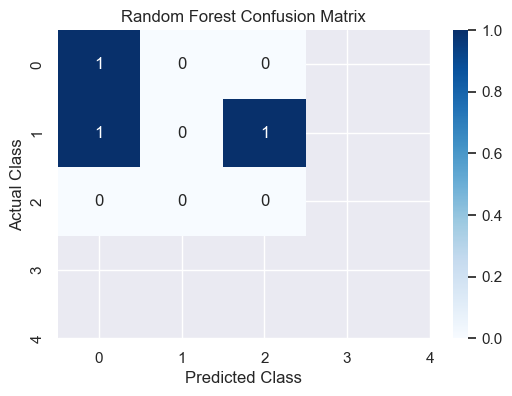

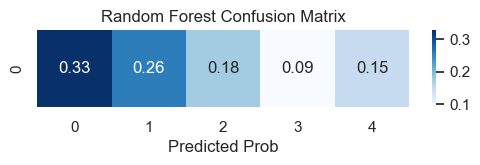

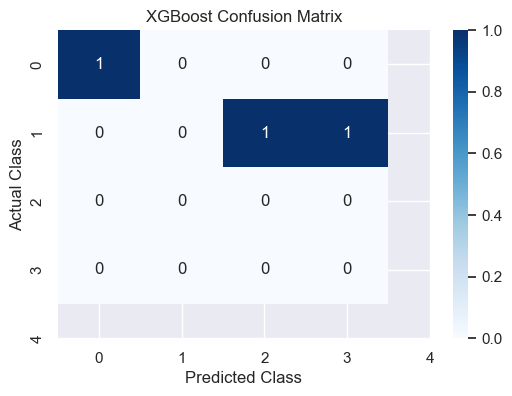

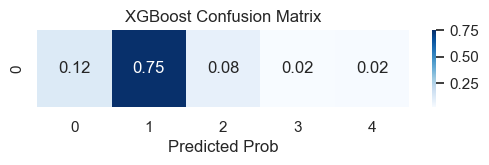

In [54]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_home_frw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model vs Home

In [55]:
target = "GAC"  # Goals For

# Separate features and target
X = df_home_ga.drop(columns=[target])
y = df_home_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [56]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [57]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

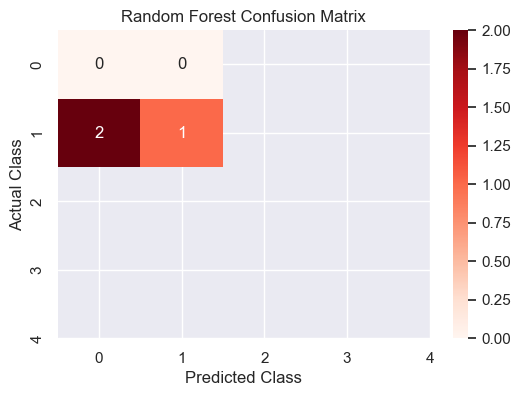

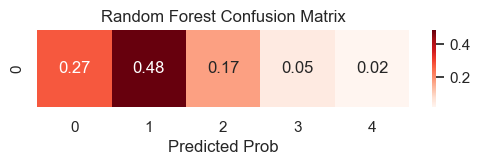

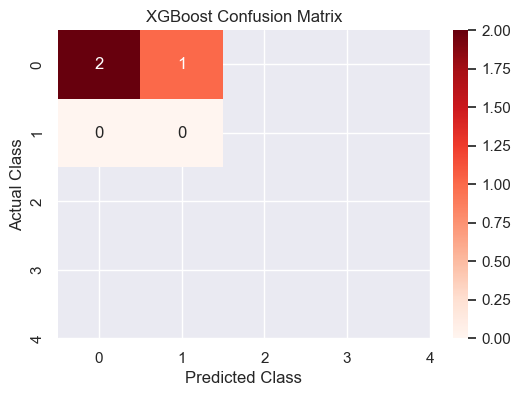

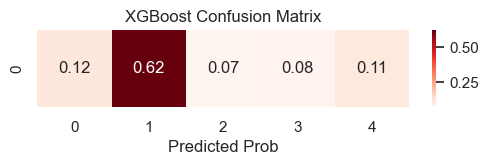

In [58]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_home_bcw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Reds', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model Away

In [59]:
target = "GFC"  # Goals For

# Separate features and target
X = df_away_gf.drop(columns=[target])
y = df_away_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [60]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [61]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

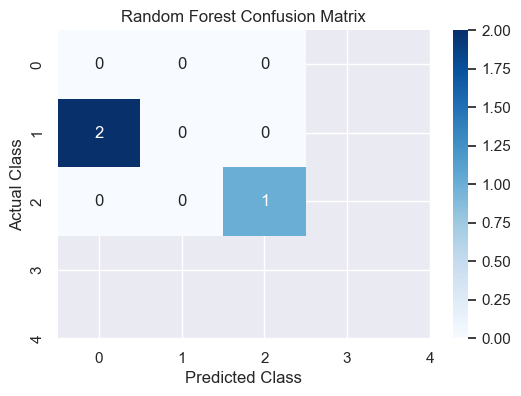

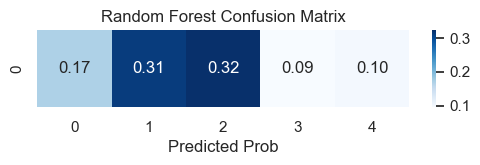

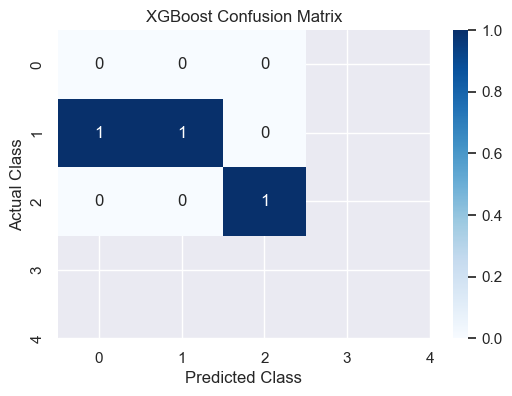

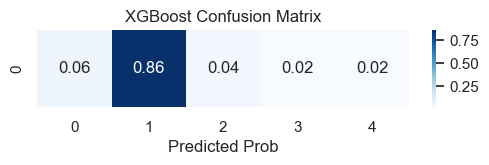

In [62]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_away_frw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model vs Away

In [63]:
target = "GAC"  # Goals For

# Separate features and target
X = df_away_ga.drop(columns=[target])
y = df_away_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [64]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [65]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

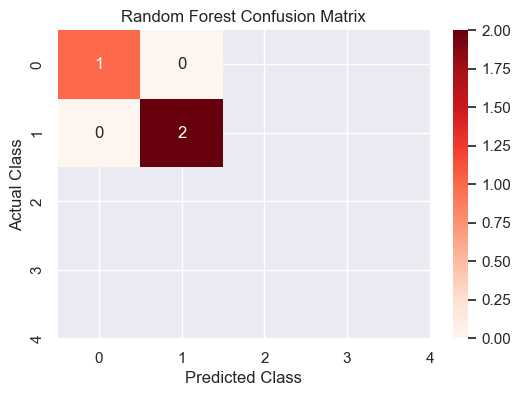

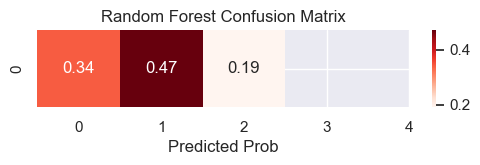

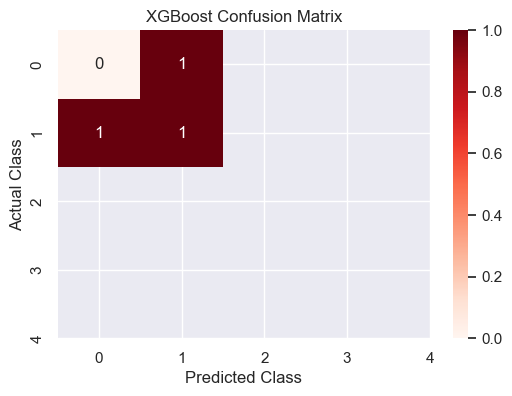

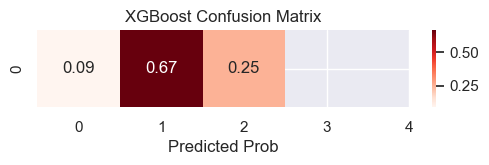

In [66]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_away_bcw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Reds', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

## Regression

### Model Home

In [67]:
target = "Tm_PTS"  # Goals For

# Separate features and target
X = df_home_gf.drop(columns=[target])
y = df_home_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [68]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [69]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

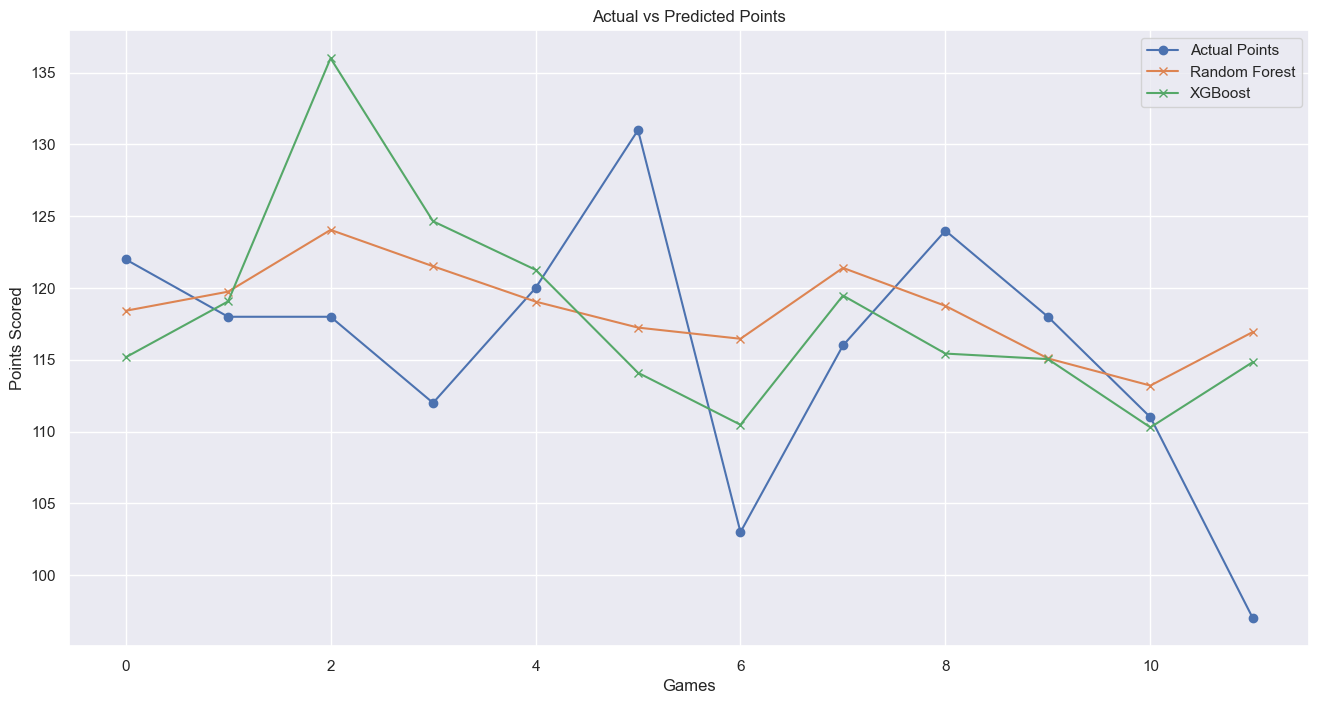

In [85]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

# Split into training and testing sets
train_size = int(len(X) * 0.8)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
# Train and evaluate each model
results = {}
plt.figure(figsize=(16,8))
plt.plot(y_test.values, label='Actual Points', marker='o')
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    plt.plot(y_pred, label=name, marker='x')
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_home_frw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred[0]}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T
plt.legend()
plt.title("Actual vs Predicted Points")
plt.xlabel("Games")
plt.ylabel("Points Scored")
plt.show()

In [80]:
results_df

,MAE,RMSE,PRED
Random Forest,7.063876,9.047376,117.443289
XGBoost,8.145854,10.362132,118.500099


### Model vs Home

In [48]:
target = "Opp_PTS"  # Goals For

# Separate features and target
X = df_home_ga.drop(columns=[target])
y = df_home_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [49]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [50]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 13.425
RMSE: 14.329


In [52]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_home_bcw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000991 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6818
[LightGBM] [Info] Number of data points in the train set: 52, number of used features: 405
[LightGBM] [Info] Start training from score 108.211538
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

In [53]:
results_df

,MAE,RMSE,PRED
Random Forest,13.041667,13.840622,[108.75]
XGBoost,13.151134,15.03493,[113.32865]
LightGBM,16.852781,18.445559,[102.71760442340414]
Linear Regression,24.528301,25.202121,[84.73789959470245]


### Model Away

In [54]:
target = "Tm_PTS"  # Goals For

# Separate features and target
X = df_away_gf.drop(columns=[target])
y = df_away_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [55]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [57]:
model_pipeline2 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline2.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline2.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 12.708
RMSE: 14.490


In [59]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_away_frw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000461 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6654
[LightGBM] [Info] Number of data points in the train set: 51, number of used features: 405
[LightGBM] [Info] Start training from score 121.941176
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [60]:
results_df

,MAE,RMSE,PRED
Random Forest,14.915,16.475376,[120.74]
XGBoost,12.521159,13.834184,[121.489395]
LightGBM,13.837515,17.031631,[126.221659266553]
Linear Regression,14.006226,16.370987,[137.60611314295068]


### Model vs Away

In [61]:
target = "Opp_PTS"  # Goals For

# Separate features and target
X = df_away_ga.drop(columns=[target])
y = df_away_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [62]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [63]:
model_pipeline2 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline2.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline2.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 10.350
RMSE: 11.309


In [65]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_away_bcw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000408 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6692
[LightGBM] [Info] Number of data points in the train set: 51, number of used features: 405
[LightGBM] [Info] Start training from score 110.666667
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [66]:
results_df

,MAE,RMSE,PRED
Random Forest,11.596667,12.906048,[108.99]
XGBoost,15.120514,16.820382,[102.5551]
LightGBM,9.838286,11.897321,[109.56588285586935]
Linear Regression,14.973625,19.146221,[86.82162740707135]
